Practical 9 Extra

Name:Vedanti Ramde

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/ml_dataset/WineQT.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [ ]:
#X = df[['Annual Income(k$)', 'Spending Score(1-1000)]]
X = df.iloc[:,[3,4]].values

In [ ]:
print(X)

[[1.9   0.076]
 [2.6   0.098]
 [2.3   0.092]
 ...
 [2.    0.09 ]
 [2.2   0.062]
 [2.    0.075]]


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

[2286.000000000005, 1501.3598860914428, 761.3961622476105, 633.4432682350536, 505.9773376469779, 364.2213841246995, 287.7285247528405, 255.17523035093964, 220.57760600687706, 196.71283427684477]


Text(0.5, 1.0, 'Elbow Method for Optimal K')

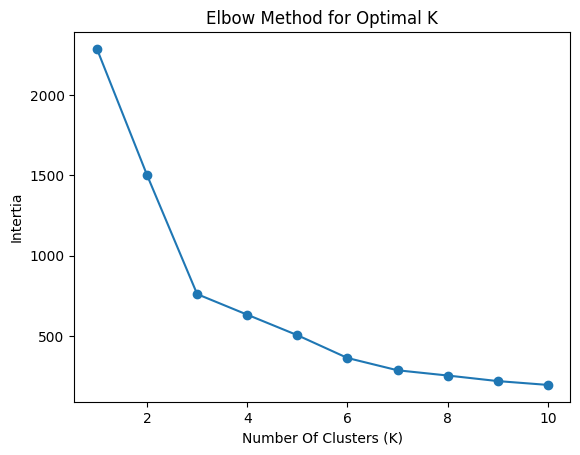

In [ ]:
inertia_values = []
for k in range(1,11):
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(X_scaled)
  inertia_values.append(kmeans.inertia_)
print(inertia_values)
plt.figure()
plt.plot(range(1,11),inertia_values, marker='o')
plt.xlabel("Number Of Clusters (K)")
plt.ylabel("Intertia")
plt.title("Elbow Method for Optimal K")


In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['cluster'] = clusters
print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  cluster  
0      9.4        5   0        4  
1      9.8      

In [ ]:
print("Inertia:", kmeans.inertia_)
sil_score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:",sil_score)

Inertia: 505.9773376469779
Silhouette Score: 0.42982277061503094
